# Functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from matplotlib.patches import Patch
from typing import Optional, Any, List, Sequence, Dict, Tuple

BASE_PATH = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/100results/"

def load_and_concat(data_info: pd.DataFrame, base_path = BASE_PATH) -> pd.DataFrame:
    tables = []
    meta_cols = [c for c in data_info.columns if c != "path"]

    for _, row in data_info.iterrows():
        models = {"pix2pix":"Pix2Pix","cyclegan":"CycleGAN","cut":"CUT", "pure":"Generator-only"}
        # load data
        df = pd.read_csv(base_path + row["path"])
        try:
            df["bodyregion"] = df["file_name"].str.split("_").str[0]
        except:
            df["bodyregion"] = df["volume_id"].str.split("_").str[0]
        
        if row["path"].split("_")[0] in ["3", "2"]:
            df["model"] = models[row["path"].split("_")[2]]
        else:
            df["model"] = models[row["path"].split("_")[0]]

        # drop missing values and display warning if more than 5% of data
        old_len = len(df)
        df = df.dropna()
        new_len = len(df)
        dropped_rows = old_len - new_len
        if dropped_rows/old_len > 0.05:
            folder = row["path"].split("/")[0]
            print(f"{folder}: dropping {round(dropped_rows/old_len, 4)*100}% of rows ({dropped_rows} slices) due to missing values")

        # for full-body, filter for the respective body region
        if row["region_or_fullbody"] == "Fullbody":
            assert len(df["bodyregion"].unique()) == 5, f"Not enough bodyregions in testing output for {row['path']}"
        else:
            assert len(df["bodyregion"].unique()) == 1, f"Too many bodyregions in testing output for {row['path']}"

        # attach metadata columns
        for col in meta_cols:
            df[col] = row[col]

        # reorder: metadata first, then CSV columns
        df = df[meta_cols + [c for c in df.columns if c not in meta_cols]]

        tables.append(df)

    return pd.concat(tables, ignore_index=True)

def plot_grouped_boxplots(
    df: pd.DataFrame,
    filter_column: str,
    filter_value: Any,
    metric: str,
    groups: List[str],
    *,
    figsize=(12, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if filter_column not in df.columns:
        raise KeyError(f"filter_column={filter_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df[df[filter_column] == filter_value].copy()
    dff = dff.dropna(subset=[metric])
    if dff.empty:
        raise ValueError("No data after filtering / dropping NaNs")
    
    # --- Uniqueness / aggregation warning ---
    base_check_cols = ["bodyregion", "model", "region_or_fullbody", "preprocessing"]
    check_cols = [c for c in base_check_cols if c not in groups]
    n_combos = dff[check_cols].drop_duplicates().shape[0]
    assert n_combos == 1, f"Values are aggregated across multiple combinations of {check_cols} (found {n_combos} unique combination(s) in the filtered data)."

    fig, ax = plt.subplots(figsize=figsize)
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    default_color0 = cycle[0] if cycle else "C0"

    if len(groups) == 1:
        g1 = groups[0]
        order1 = list(pd.unique(dff[g1]))

        data = [dff.loc[dff[g1] == k, metric].values for k in order1]
        bp = ax.boxplot(
            data,
            labels=order1,
            showfliers=showfliers,
            patch_artist=True,
            medianprops={"color": "black"},
        )
        # Use first default color as background for all boxes
        for box in bp["boxes"]:
            box.set_facecolor(default_color0)

        ax.set_xlabel(g1)

    else:
        g1, g2 = groups
        order1 = list(pd.unique(dff[g1]))
        order2 = list(pd.unique(dff[g2]))

        data = []
        positions = []
        tick_positions = []
        tick_labels = []

        colors = {k: cycle[i % len(cycle)] for i, k in enumerate(order2)}
        legend_handles = [
            Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2
        ]

        gap_within = 1.0
        gap_between = 1.0
        width = 0.7

        pos = 1.0
        for a in order1:
            start = pos
            for b in order2:
                vals = dff.loc[(dff[g1] == a) & (dff[g2] == b), metric].values
                data.append(vals)
                positions.append(pos)
                pos += gap_within

            end = pos - gap_within
            tick_positions.append((start + end) / 2.0)
            tick_labels.append(str(a))
            pos += gap_between

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops={"color": "black"},
        )

        for i, box in enumerate(bp["boxes"]):
            b = order2[i % len(order2)]
            box.set_facecolor(colors[b])

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlabel(g1)

        # Legend outside on the right
        ax.legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else g2),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} | {filter_column}={filter_value}")
    ax.grid(True, axis="y", alpha=0.3)

    # Make room for the outside legend (only matters when groups==2, harmless otherwise)
    plt.tight_layout(rect=(0, 0, 0.85, 1))
    plt.show()


def plot_metric_with_subplots(
    df: pd.DataFrame,
    metric: str,
    subplot_column: str,
    groups: List[str],
    *,
    figsize_per_subplot: tuple = (3, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    """
    Create a single figure with subplots for each unique value in subplot_column.
    All subplots share the same y-axis scale and are arranged horizontally.
    
    Parameters
    ----------
    df : pd.DataFrame
        The data to plot.
    metric : str
        The metric column to plot (MAE, MSE, PSNR, or SSIM).
    subplot_column : str
        Column to split into subplots (e.g., "bodyregion" or "preprocessing").
    groups : List[str]
        Grouping columns for boxplots within each subplot (1 or 2 columns).
    figsize_per_subplot : tuple
        Width and height per subplot.
    showfliers : bool
        Whether to show outliers in boxplots.
    title : Optional[str]
        Overall figure title.
    legend_title : Optional[str]
        Title for the legend (defaults to second group name if 2 groups).
    """
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    metrics_titles = {"MAE":"MAE ↓", "MSE":"MSE ↓", "PSNR":"PSNR ↑", "SSIM":"SSIM ↑"}

    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if subplot_column not in df.columns:
        raise KeyError(f"subplot_column={subplot_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df.dropna(subset=[metric]).copy()
    if dff.empty:
        raise ValueError("No data after dropping NaNs")

    subplot_values = list(pd.unique(dff[subplot_column]))
    n_subplots = len(subplot_values)

    fig, axes = plt.subplots(
        1, n_subplots,
        figsize=(figsize_per_subplot[0] * n_subplots, figsize_per_subplot[1]),
        sharey=True,
    )
    if n_subplots == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    default_color0 = cycle[0] if cycle else "C0"

    legend_handles = None

    for idx, (ax, subplot_val) in enumerate(zip(axes, subplot_values)):
        sub_df = dff[dff[subplot_column] == subplot_val]

        if len(groups) == 1:
            g1 = groups[0]
            order1 = list(pd.unique(dff[g1]))

            data = [sub_df.loc[sub_df[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

            ax.set_xlabel(g1)

        else:
            g1, g2 = groups
            order1 = list(pd.unique(dff[g1]))
            order2 = list(pd.unique(dff[g2]))

            colors = {k: cycle[i % len(cycle)] for i, k in enumerate(order2)}
            if legend_handles is None:
                legend_handles = [
                    Patch(facecolor=colors[k], edgecolor="black", label=str(k))
                    for k in order2
                ]

            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = sub_df.loc[(sub_df[g1] == a) & (sub_df[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.set_xlabel(g1)

        ax.set_title(str(subplot_val))
        ax.grid(True, axis="y", alpha=0.3)

        if idx == 0:
            ax.set_ylabel(metric)

    # Add legend to the right of the last subplot
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    fig.suptitle(title or metrics_titles[metric], fontsize=20, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_metric_with_subplots_incl_total(
    df: pd.DataFrame,
    metric: str,
    subplot_column: str,
    groups: List[str],
    *,
    figsize_per_subplot: tuple = (3, 6),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
    fig: Optional[plt.Figure] = None,
    axes: Optional[Sequence[plt.Axes]] = None,
    add_legend: bool = True,
    show: bool = True,
):
    """
    Create a single figure with subplots for each unique value in subplot_column,
    plus an additional final subplot "Total" that aggregates across all subplot values.

    All subplots share the same y-axis scale and are arranged horizontally.

    Parameters
    ----------
    df : pd.DataFrame
        The data to plot.
    metric : str
        The metric column to plot (MAE, MSE, PSNR, or SSIM).
    subplot_column : str
        Column to split into subplots (e.g., "bodyregion" or "preprocessing").
        The "Total" subplot ignores this split and uses all rows.
    groups : List[str]
        Grouping columns for boxplots within each subplot (1 or 2 columns).
    figsize_per_subplot : tuple
        Width and height per subplot.
    showfliers : bool
        Whether to show outliers in boxplots.
    title : Optional[str]
        Overall figure title.
    legend_title : Optional[str]
        Title for the legend (defaults to second group name if 2 groups).
    """
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    metrics_titles = {"MAE": "MAE ↓", "MSE": "MSE ↓", "PSNR": "PSNR ↑", "SSIM": "SSIM ↑"}

    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if subplot_column not in df.columns:
        raise KeyError(f"subplot_column={subplot_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df.dropna(subset=[metric]).copy()
    if dff.empty:
        raise ValueError("No data after dropping NaNs")

    subplot_values = list(pd.unique(dff[subplot_column]))
    subplot_values_incl_total = subplot_values + ["Total"]
    n_subplots = len(subplot_values_incl_total)

    # --- create axes only if not provided ---
    if axes is None:
        fig, axes = plt.subplots(
            1, n_subplots,
            figsize=(figsize_per_subplot[0] * n_subplots, figsize_per_subplot[1]),
            sharey=True,
        )
        if n_subplots == 1:
            axes = [axes]
    else:
        # assume caller passes the right number of axes
        axes = list(axes)
        if fig is None:
            fig = axes[0].figure

    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    default_color0 = cycle[0] if cycle else "C0"

    legend_handles = None

    for idx, (ax, subplot_val) in enumerate(zip(axes, subplot_values_incl_total)):
        region_titles = {"AB":"Abdomen","TH":"Thorax","HN":"Head-Neck","Total":"TOTAL","brain":"Brain","pelvis":"Pelvis"}
        if subplot_val == "Total":
            sub_df = dff
        else:
            sub_df = dff[dff[subplot_column] == subplot_val]

        if len(groups) == 1:
            g1 = groups[0]
            order1 = list(pd.unique(dff[g1]))

            data = [sub_df.loc[sub_df[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

            ax.set_xlabel(g1)

        else:
            g1, g2 = groups
            order1 = list(pd.unique(dff[g1]))
            order2 = list(pd.unique(dff[g2]))

            # Colors keyed by g2, consistent across all subplots (including Total)
            colors = {k: cycle[i % len(cycle)] if cycle else f"C{i}" for i, k in enumerate(order2)}

            if legend_handles is None:
                legend_handles = [
                    Patch(facecolor=colors[k], edgecolor="black", label=str(k))
                    for k in order2
                ]

            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = sub_df.loc[(sub_df[g1] == a) & (sub_df[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            # ax.set_xlabel(g1)

        ax.set_title(str(region_titles[subplot_val]))
        ax.grid(True, axis="y", alpha=0.3)

        if idx == 0:
            ax.set_ylabel(metric)

    # Add legend to the right of the last subplot
    if len(groups) == 2 and legend_handles is not None and add_legend:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    if title is not None:
        fig.suptitle(title or metrics_titles[metric], fontsize=20, fontweight="bold")

    # only layout/show if we created the figure (or if caller asks)
    if show:
        plt.tight_layout()
        plt.show()

    return fig, axes

def split_masked_unmasked(df: pd.DataFrame):
    """
    Returns two DataFrames:
    - masked_df: columns ending with '_masked' plus columns without '_masked' or '_unmasked'
    - unmasked_df: columns ending with '_unmasked' plus columns without '_masked' or '_unmasked'
    
    In both outputs, the suffix '_masked' or '_unmasked' is removed from column names.
    """
    masked_cols = []
    unmasked_cols = []
    common_cols = []

    for col in df.columns:
        if col.endswith("_masked"):
            masked_cols.append(col)
        elif col.endswith("_unmasked"):
            unmasked_cols.append(col)
        else:
            common_cols.append(col)

    masked_df = df[common_cols + masked_cols].copy()
    unmasked_df = df[common_cols + unmasked_cols].copy()

    masked_df.columns = [
        col[:-7] if col.endswith("_masked") else col for col in masked_df.columns
    ]
    unmasked_df.columns = [
        col[:-9] if col.endswith("_unmasked") else col for col in unmasked_df.columns
    ]

    return masked_df, unmasked_df


def plot_multiple_metrics_with_subplots(
    df: pd.DataFrame,
    metrics: Sequence[str],
    groups: List[str],
    *,
    # optional filtering (e.g., lock to preprocessing="Baseline")
    filter_column: Optional[str] = None,
    filter_value: Optional[Any] = None,
    # layout/styling
    figsize_per_subplot: tuple = (4, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
    metric_titles: Optional[Dict[str, str]] = None,
    sharey: bool = False,
):
    """
    One figure with one subplot per metric (no split by bodyregion).
    Each subplot shows grouped boxplots based on `groups` (len 1 or 2).

    Parameters
    ----------
    df : pd.DataFrame
    metrics : list/tuple of metric column names
    groups : 1 or 2 columns to group boxplots (same semantics as your existing functions)
    filter_column/filter_value : optional filter applied before plotting
    figsize_per_subplot : (width, height) per metric subplot
    showfliers : whether to show outliers
    title : overall figure title
    legend_title : title for legend (defaults to groups[1] if 2 groups)
    metric_titles : mapping metric -> display title (optional)
    sharey : if True, share y-axis across metrics (usually False since scales differ)
    """
    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    for m in metrics:
        if m not in df.columns:
            raise KeyError(f"metric {m!r} not in df.columns")

    dff = df.copy()

    if filter_column is not None:
        if filter_column not in dff.columns:
            raise KeyError(f"filter_column={filter_column} not in df.columns")
        dff = dff[dff[filter_column] == filter_value].copy()

    # drop rows missing any plotted metric (keeps comparisons consistent)
    dff = dff.dropna(subset=list(metrics))
    if dff.empty:
        raise ValueError("No data after filtering / dropping NaNs")

    n = len(metrics)
    fig, axes = plt.subplots(
        1, n,
        figsize=(figsize_per_subplot[0] * n, figsize_per_subplot[1]),
        sharey=sharey,
    )
    if n == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    default_color0 = cycle[0] if cycle else "C0"

    # consistent ordering across all metric subplots
    if len(groups) == 1:
        g1 = groups[0]
        order1 = list(pd.unique(dff[g1]))
        legend_handles = None
    else:
        g1, g2 = groups
        order1 = list(pd.unique(dff[g1]))
        order2 = list(pd.unique(dff[g2]))
        cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])

        colors = {}
        for i, k in enumerate(order2):
            if i == 3:  # fourth color (0-based index)
                colors[k] = "grey"
            else:
                colors[k] = cycle[i % len(cycle)] if cycle else f"C{i}"
        legend_handles = [Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2]

    # default nice titles if you want arrows
    default_metric_titles = {
        "MAE": "MAE ↓", "MSE": "MSE ↓", "PSNR": "PSNR ↑", "SSIM": "SSIM ↑",
        'HD95':'HD95 ↓', 'DICE':'DICE ↑', 'MS-SSIM':'MS-SSIM ↑',
        'GPR 2mm/2% (photon)':'GPR 2mm/2% (photon) ↑', 'GPR 2mm/2% (proton)':'GPR 2mm/2% (proton) ↑',
        'DVH error (photon)':'DVH error (photon) ↓', 'DVH error (proton)':'DVH error (proton) ↓',
        'Dose MAE (photon)':'Dose MAE (photon) ↓', 'Dose MAE (proton)':'Dose MAE (proton) ↓'}
    metric_titles = metric_titles or {}

    for ax, metric in zip(axes, metrics):
        if len(groups) == 1:
            data = [dff.loc[dff[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)
            # ax.set_xlabel(g1)

        else:
            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = dff.loc[(dff[g1] == a) & (dff[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            # ax.set_xlabel(g1)

        ax.set_title(metric_titles.get(metric, default_metric_titles.get(metric, metric)), fontweight="bold")
        ax.grid(True, axis="y", alpha=0.3)

    # y labels: either per axis or just the first one
    if sharey:
        axes[0].set_ylabel("Value")
    else:
        for ax, metric in zip(axes, metrics):
            ax.set_ylabel(metric)

    # one legend for whole figure (right side), only when groups==2
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )
        plt.tight_layout(rect=(0, 0, 0.88, 1))
    else:
        plt.tight_layout()

    if title is not None:
        fig.suptitle(title, fontsize=16, fontweight="bold")
        # if you set a suptitle after tight_layout, give it some room:
        plt.subplots_adjust(top=0.85)

    plt.show()
    return fig

def plot_multiple_metrics_with_subplots_on_axes(
    df: pd.DataFrame,
    metrics: Sequence[str],
    groups: List[str],
    *,
    axes,
    fig=None,
    filter_column: Optional[str] = None,
    filter_value: Optional[Any] = None,
    showfliers: bool = False,
    legend_title: Optional[str] = None,
    metric_titles: Optional[Dict[str, str]] = None,
    sharey: bool = False,
    add_legend: bool = True,
    show: bool = False,
):
    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    for m in metrics:
        if m not in df.columns:
            raise KeyError(f"metric {m!r} not in df.columns")

    dff = df.copy()

    if filter_column is not None:
        if filter_column not in dff.columns:
            raise KeyError(f"filter_column={filter_column} not in df.columns")
        dff = dff[dff[filter_column] == filter_value].copy()

    dff = dff.dropna(subset=list(metrics))
    if dff.empty:
        raise ValueError("No data after filtering / dropping NaNs")

    if fig is None:
        fig = axes[0].figure

    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    default_color0 = cycle[0] if cycle else "C0"

    # consistent ordering across all metric subplots
    if len(groups) == 1:
        g1 = groups[0]
        order1 = list(pd.unique(dff[g1]))
        legend_handles = None
    else:
        g1, g2 = groups
        order1 = list(pd.unique(dff[g1]))
        order2 = list(pd.unique(dff[g2]))
        colors = {k: (cycle[i % len(cycle)] if cycle else f"C{i}") for i, k in enumerate(order2)}
        legend_handles = [Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2]

    default_metric_titles = {
        "MAE": "MAE ↓", "MSE": "MSE ↓", "PSNR": "PSNR ↑", "SSIM": "SSIM ↑",
        'HD95':'HD95 ↓', 'DICE':'DICE ↑', 'MS-SSIM':'MS-SSIM ↑',
        'GPR 2mm/2% (photon)':'GPR 2mm/2% (photon) ↑', 'GPR 2mm/2% (proton)':'GPR 2mm/2% (proton) ↑',
        'DVH error (photon)':'DVH error (photon) ↓', 'DVH error (proton)':'DVH error (proton) ↓',
        'Dose MAE (photon)':'Dose MAE (photon) ↓', 'Dose MAE (proton)':'Dose MAE (proton) ↓'
    }
    metric_titles = metric_titles or {}

    if len(axes) != len(metrics):
        raise ValueError(f"Need exactly {len(metrics)} axes, got {len(axes)}")

    for ax, metric in zip(axes, metrics):
        if len(groups) == 1:
            data = [dff.loc[dff[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

        else:
            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = dff.loc[(dff[g1] == a) & (dff[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)

        ax.set_title(metric_titles.get(metric, default_metric_titles.get(metric, metric)), fontweight="bold")
        ax.grid(True, axis="y", alpha=0.3)

    if sharey:
        axes[0].set_ylabel("Value")
    else:
        for ax, metric in zip(axes, metrics):
            ax.set_ylabel(metric)

    # legend only if requested (and groups==2)
    if add_legend and len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    if show:
        plt.show()

    return fig


def metrics_mean_std_by_region_model(
    df: pd.DataFrame,
    group_cols=("model", "region_or_fullbody"),
    metric_cols=("MAE", "MSE", "PSNR", "SSIM"),
    decimals={"MAE": 2, "MSE": 0, "PSNR": 2, "SSIM": 3},
    pm=" ± ",
) -> pd.DataFrame:
    """
    Returns a wide table with one row per (region_or_fullbody, model) and columns:
      MAE, MSE, PSNR, SSIM formatted as 'mean ± std'.

    Example output columns: [region_or_fullbody, model, MAE, MSE, PSNR, SSIM]
    """
    if decimals is None:
        decimals = {m: 2 for m in metric_cols}  # sensible default

    # aggregate
    agg = (
        df.loc[:, list(group_cols) + list(metric_cols)]
          .groupby(list(group_cols), dropna=False)
          .agg(['mean', 'std'])
    )

    # to long: (group_cols, metric, stat, value)
    long = (
        agg.stack(0)  # metric level
           .rename_axis(index=list(group_cols) + ["metric"])
           .reset_index()
    )

    # format "mean ± std" with thousands separator "'"
    def _fmt(row):
        d = decimals.get(row["metric"], 3)
        mean = row["mean"]
        std = row["std"]

        if pd.isna(mean) or pd.isna(std):
            return ""

        mean_str = f"{mean:,.{d}f}".replace(",", "'")
        std_str  = f"{std:,.{d}f}".replace(",", "'")

        return f"{mean_str}{pm}{std_str}"

    long["mean+std"] = long.apply(_fmt, axis=1)

    # wide table: metric columns
    wide = (
        long.pivot_table(
            index=list(group_cols),
            columns="metric",
            values="mean+std",
            aggfunc="first",
        )
        .reset_index()
    )

    # keep metric column order
    for m in metric_cols:
        if m not in wide.columns:
            wide[m] = ""
    wide = wide.loc[:, list(group_cols) + list(metric_cols)]

    return wide

def calculate_wilcoxon_vs_baseline(df, metric="MAE", baseline="Baseline",
                                   within="preprocessing", subject="volume_id"):
    """
    Pairwise Wilcoxon signed-rank tests comparing each normalization strategy
    against the baseline, separately per model framework.
    
    Parameters
    ----------
    df : pd.DataFrame
        Output of load_and_concat + split_masked_unmasked.
    metric : str
        The metric to test (default: "MAE").
    baseline : str
        The reference condition to compare against.
    within : str
        The within-subject factor (normalization strategy).
    subject : str
        The patient/volume identifier column.
    
    Returns
    -------
    pd.DataFrame with one row per (framework, comparison), showing T, p-value,
    corrected p-value, effect size (RBC), and n.
    """
    results = []

    for model in df["model"].unique():
        subset = df[df["model"] == model].copy()
        conditions = [c for c in subset[within].unique() if c != baseline]

        model_results = []

        for condition in conditions:
            pair = subset[subset[within].isin([baseline, condition])]

            # Keep only patients present in both conditions
            patient_counts = pair.groupby(subject)[within].nunique()
            valid_patients = patient_counts[patient_counts == 2].index
            pair = pair[pair[subject].isin(valid_patients)]

            wide = pair.pivot_table(index=subject, columns=within, values=metric, aggfunc="mean")

            result = pg.wilcoxon(wide[baseline], wide[condition],
                                 alternative="two-sided", zero_method="pratt")

            T = result["W-val"].iloc[0]
            p = result["p-val"].iloc[0]
            effsize = result["RBC"].iloc[0] if "RBC" in result.columns else None

            model_results.append({
                "model": model,
                "comparison": f"{baseline} vs {condition}",
                "T": T,
                "p_value": round(p, 6),
                "effect_size_RBC": round(effsize, 3) if effsize is not None else None,
                "n": len(wide),
            })

        results.extend(model_results)

    return pd.DataFrame(results).set_index(["model", "comparison"])



# Experiment 1

## Volume-level metrics

/home/user/nschuler/miniconda3/envs/preprocessing_env/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


=======================results chart======================


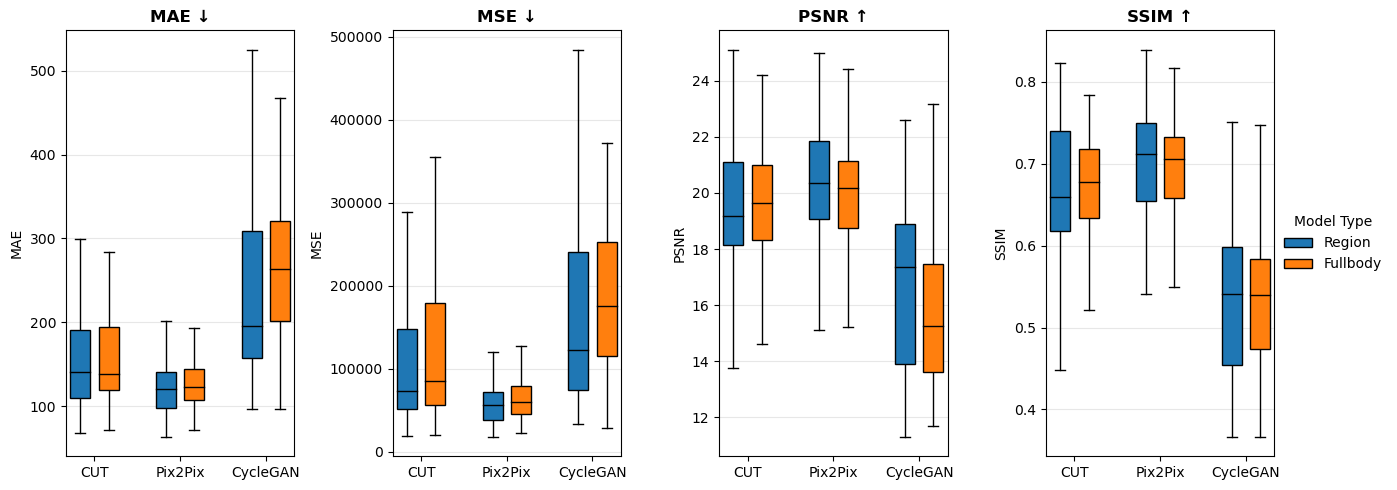

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:e1_own}
\begin{tabular}{l l c c c c}
\toprule
   model & region_or_fullbody &             MAE &               MSE &         PSNR &          SSIM \\
\midrule
     CUT &           Fullbody & 176.53 ± 110.67 & 154'865 ± 175'794 & 19.38 ± 2.52 & 0.669 ± 0.075 \\
     CUT &             Region & 174.98 ± 114.52 & 142'676 ± 178'861 & 19.30 ± 2.72 & 0.666 ± 0.092 \\
CycleGAN &           Fullbody &  257.28 ± 89.68 & 184'653 ± 100'464 & 15.94 ± 2.80 & 0.538 ± 0.085 \\
CycleGAN &             Region &  230.37 ± 91.43 & 163'022 ± 106'882 & 16.70 ± 2.88 & 0.536 ± 0.088 \\
 Pix2Pix &           Fullbody &  137.19 ± 59.92 &   77'537 ± 66'337 & 19.97 ± 1.86 & 0.687 ± 0.069 \\
 Pix2Pix &             Region &  128.76 ± 51.25 &   68'364 ± 52'284 & 20.38 ± 1.97 & 0.697 ± 0.072 \\
\bottomrule
\end{tabular}
\end{table}

=======================appendix chart======================


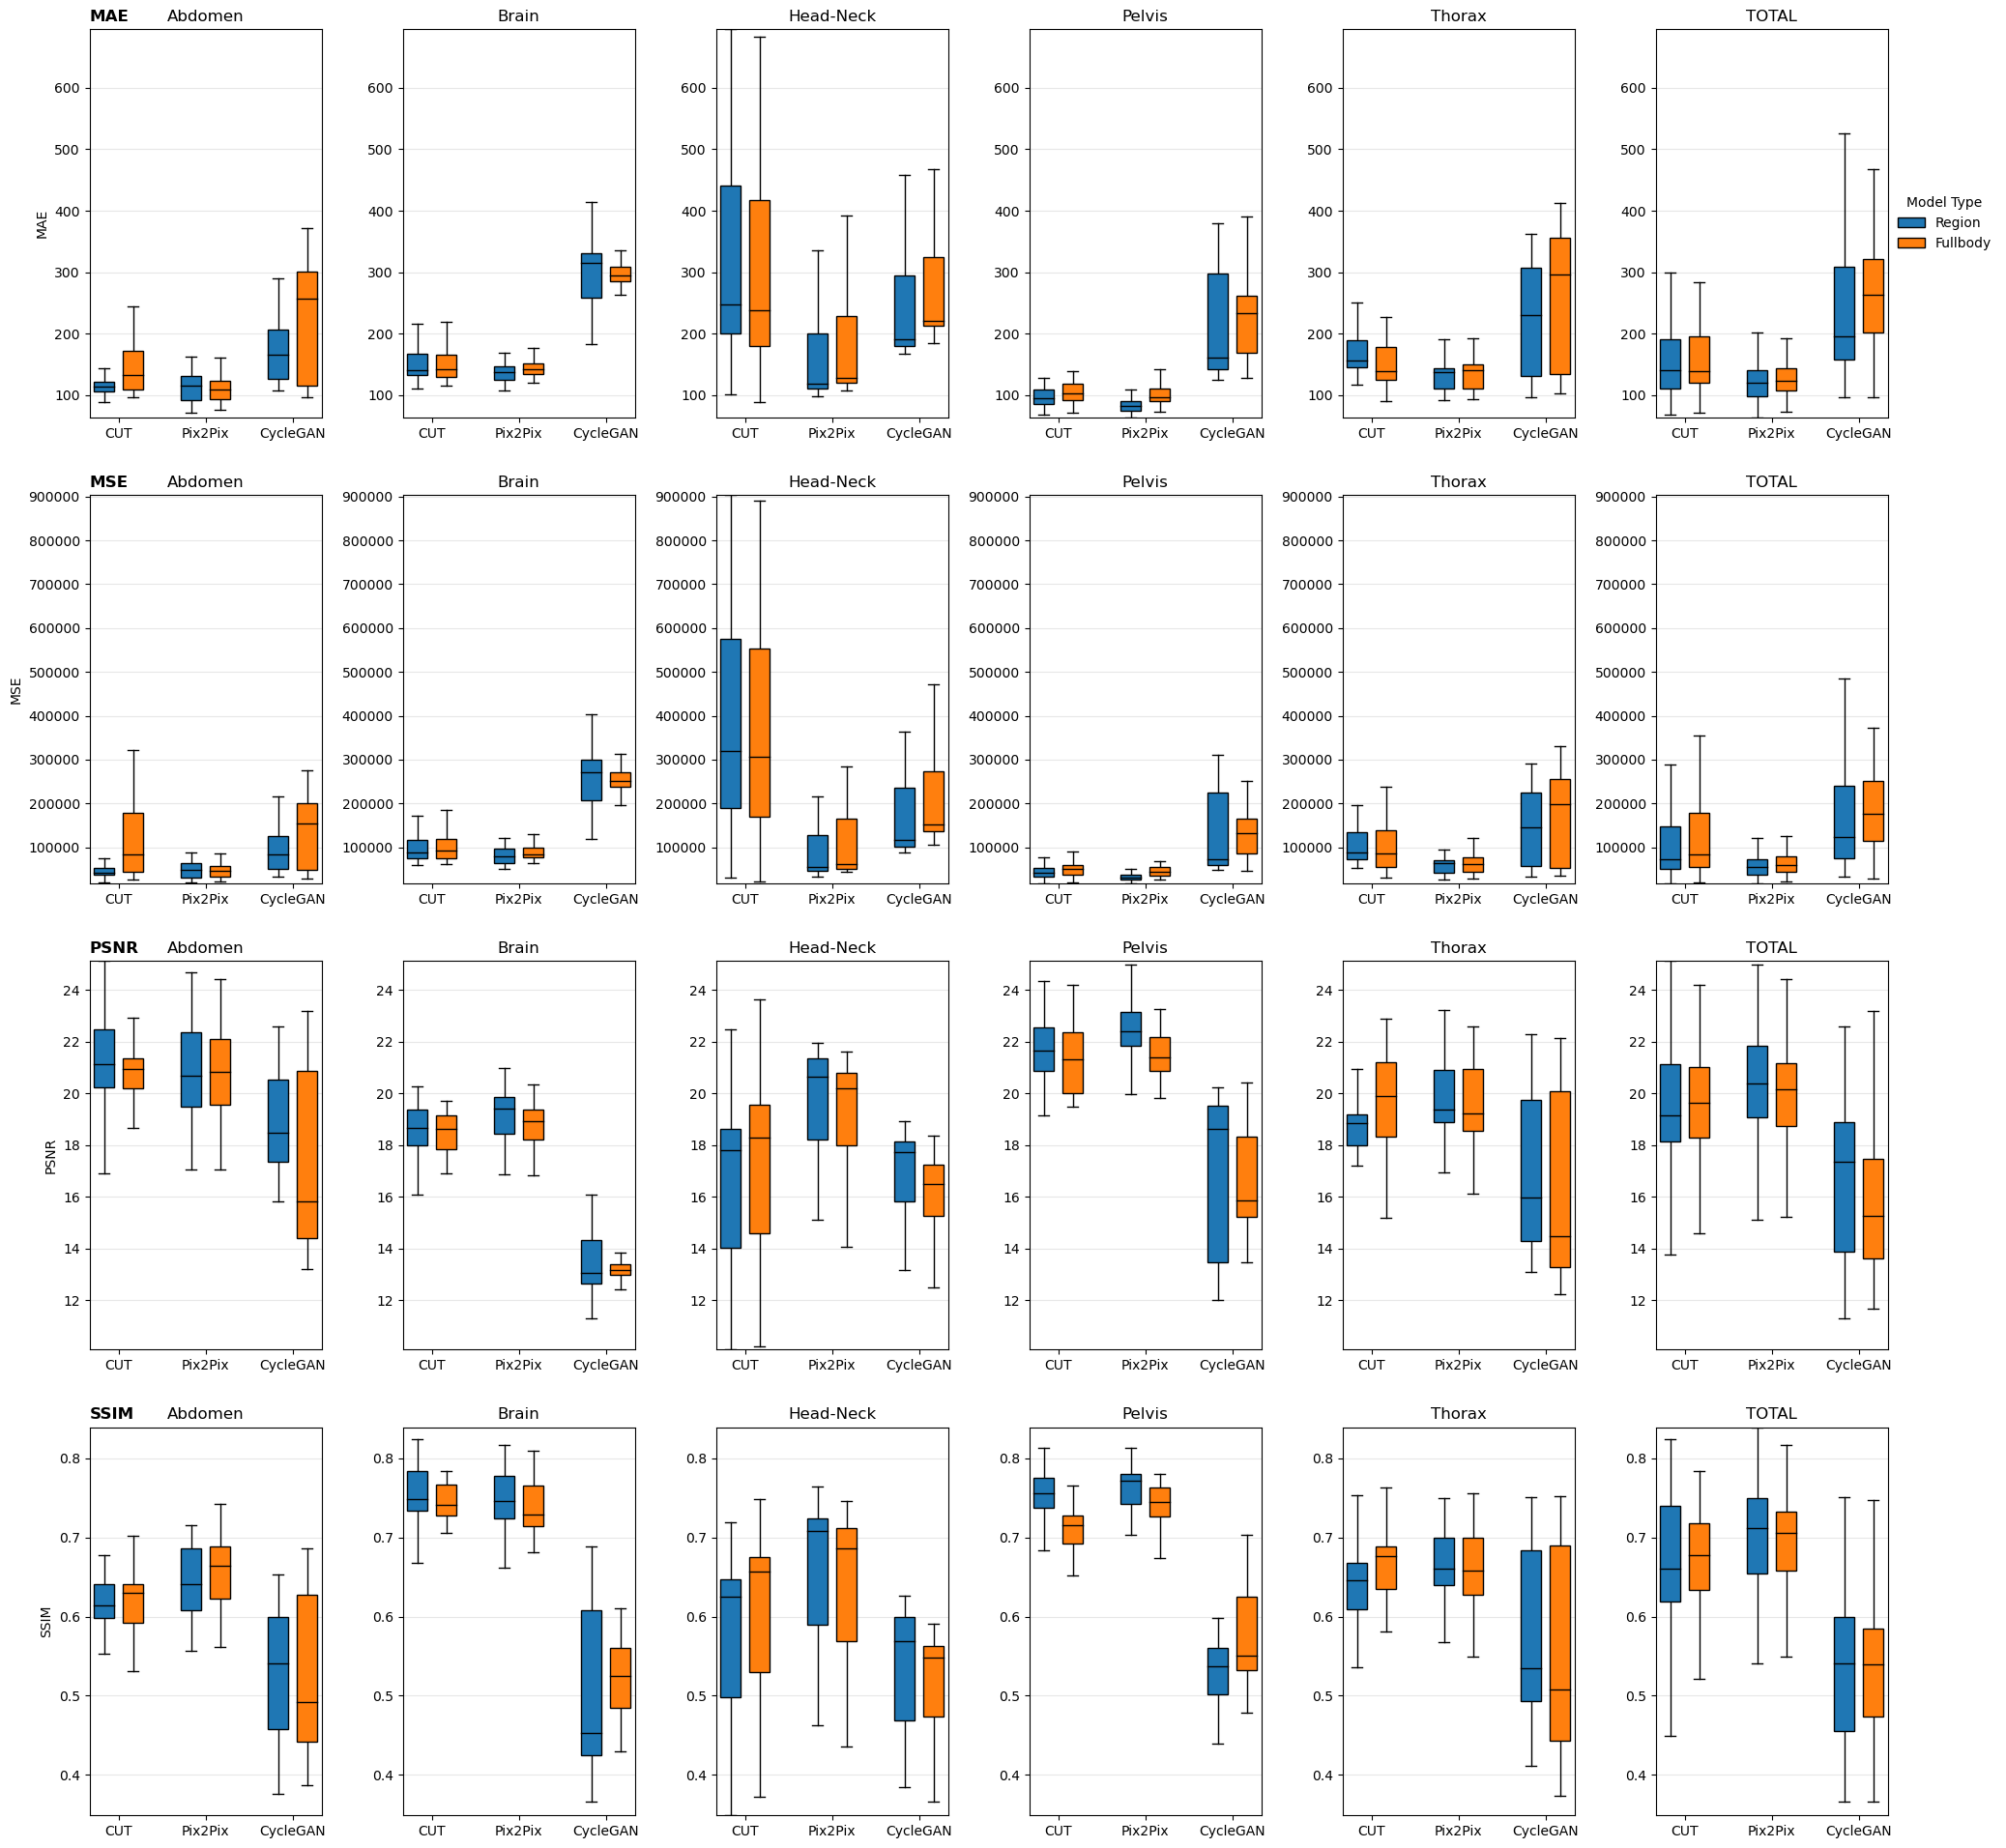

In [2]:
# Data loading
data_info_ex1_volume = pd.DataFrame(
    [
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_brain_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_HN_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_pelvis_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_TH_final/test_51/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "cut_synthrad_allregions_final/test_50/test_metrics_over_volume.csv"],

        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_brain_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_headneck_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_pelvis_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_thorax_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "pix2pix_synthrad_allregion_final/test_50/test_metrics_over_volume.csv"],
        
        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_brain_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_head_neck_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_pelvis_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_thorax_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "cyclegan_allregions_final/test_50/test_metrics_over_volume.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex1_volume)
masked, unmasked = split_masked_unmasked(all_data)

print("=======================results chart======================")
fig = plot_multiple_metrics_with_subplots(
    masked,
    metrics=["MAE", "MSE", "PSNR", "SSIM"],
    groups=["model", "region_or_fullbody"],
    legend_title="Model Type",
    # title="Ex1: Fullbody vs. Region-Specific Models, own Image Similarity-based Evaluation",
)
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Overview_Chart_Own.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Overview_Chart_Own.pdf", format="pdf", bbox_inches="tight")

results_table = metrics_mean_std_by_region_model(masked)
latex_results_table = results_table.to_latex(
        index=False,
        escape=False,
        column_format="l l c c c c",
        caption="Image similarity metrics (mean $\\pm$ std)",
        label="tab:e1_own",
    )
print(latex_results_table)
results_table

print("=======================appendix chart======================")
# for metric in ["MAE", "MSE", "PSNR", "SSIM"]:
#     plot_metric_with_subplots_incl_total(
#         masked,
#         metric=metric,
#         subplot_column="bodyregion",
#         groups=["model", "region_or_fullbody"],
#         legend_title="Model Type",
#     )
metrics = ["MAE", "MSE", "PSNR", "SSIM"]

subplot_values = list(pd.unique(masked["bodyregion"]))
n_inner = len(subplot_values) + 1  # + "Total"

fig = plt.figure(figsize=(4 * n_inner, 6 * len(metrics)))  # tweak
outer = fig.add_gridspec(len(metrics), 1, hspace=0.2)

# global limits per metric (optional: per metric instead of global-global)
y_lims = {}

for metric in metrics:
    vals = masked[metric].dropna().values
    y_lims[metric] = (vals.min(), vals.max())

for i, metric in enumerate(metrics):
    inner = outer[i, 0].subgridspec(1, n_inner, wspace=0.35)
    axes = [fig.add_subplot(inner[0, j]) for j in range(n_inner)]

    plot_metric_with_subplots_incl_total(
        masked,
        metric=metric,
        subplot_column="bodyregion",
        groups=["model", "region_or_fullbody"],
        legend_title="Model Type",
        fig=fig,
        axes=axes,
        add_legend=(i == 0),  # show legend only once (top row)
        show=False,
        title=None,
    )
    axes[0].set_title(metric, loc="left", fontweight="bold")
    for ax in axes:
        ax.set_ylim(y_lims[metric])

# fig.suptitle("Experiment 1 Results by anatomical region and aggregated", fontsize=18, fontweight="bold")
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Detail_Chart.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Detail_Chart.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Synthrad Results

In [3]:
import json
from pathlib import Path
import pandas as pd

filenames = [
    "top1_testtask_KoalAI.json",
    # "top2_testtask_ImagePasNet.json",
    # "top3_testtask_BreizhCT.json",
    "cut_allregions.json",
    "cut_region_specific.json",
    "cycleGAN_allregions.json",
    "cycleGAN_region_specific.json",
    "pix2pix_allregions.json",
    "pix2pix_region_specific.json",
]

# mapping dictionary
model_map = {
   "cut":"CUT",
   "cycleGAN":"CycleGAN",
   "pix2pix":"Pix2Pix",
   "synthrad_winners":"Winners"
}
region_or_fullbody_map = {
    "allregions": "Fullbody",
    "region_specific":"Region",
    "synthrad_winners":"Region"
}

def parse_filename(fname):
    if fname.startswith("top"):
        return pd.Series({
            "filename": fname,
            "model": "synthrad_winners",
            "region_or_fullbody": "synthrad_winners",
        })
    else:
        family, mtype = fname.replace(".json", "").split("_", 1)
        return pd.Series({
            "filename": fname,
            "model": family,
            "region_or_fullbody": mtype,
        })


def load_results_and_aggregates(
    df: pd.DataFrame,
    base_dir: str = ".",
    filename_col: str = "filename",
):
    """
    Reads each JSON file referenced by df[filename_col] and returns:
      - results: one row per entry in json["results"]
      - aggregates: one row per metric-stat pair in json["aggregates"]

    Both outputs include all columns from the input df (e.g., filename, model_family, model_type),
    duplicated across the extracted rows.
    """
    base_dir = Path(base_dir)

    results_rows = []
    aggregates_rows = []

    meta_cols = [c for c in df.columns]  # keep all columns from df

    for _, row in df.iterrows():
        fname = row[filename_col]
        meta = row[meta_cols].to_dict()
        fpath = base_dir / fname

        with fpath.open("r", encoding="utf-8") as f:
            payload = json.load(f)

        # --- results (list of dicts) ---
        res_list = payload.get("results", [])
        if res_list is None:
            res_list = []
        for i, metrics in enumerate(res_list):
            out = dict(meta)
            out["result_index"] = i
            if isinstance(metrics, dict):
                out.update(metrics)
            results_rows.append(out)

        # --- aggregates (nested dict: metric -> stat -> value) ---
        aggs = payload.get("aggregates", {}) or {}
        for metric_name, stats_dict in aggs.items():
            if not isinstance(stats_dict, dict):
                continue
            for stat_name, stat_value in stats_dict.items():
                aggregates_rows.append(
                    {
                        **meta,
                        "metric": metric_name,
                        "stat": stat_name,
                        "value": stat_value,
                    }
                )

    results = pd.DataFrame(results_rows)
    aggregates = pd.DataFrame(aggregates_rows)

    # Optional: keep a consistent column order (meta first)
    if not results.empty:
        other_cols = [c for c in results.columns if c not in meta_cols]
        results = results[meta_cols + other_cols]
    if not aggregates.empty:
        aggregates = aggregates[meta_cols + ["metric", "stat", "value"]]

    aggregates = aggregates.pivot_table(
        index=['filename', 'model', 'region_or_fullbody', 'bodyregion', 'metric'],
        columns='stat', values='value').reset_index()
    
    # aggregates["mean+std"] = aggregates["mean"].round(3).astype(str) + " ± " + aggregates["std"].round(3).astype(str)
    def format_row(row):
        d = 3 if row["metric"] in ["mae_proton", "mae_photon"] else 2
        return f"{row['mean']:.{d}f} ± {row['std']:.{d}f}"

    aggregates["mean+std"] = aggregates.apply(format_row, axis=1)
    aggregates["model"] = aggregates["model"].map(model_map)
    aggregates["region_or_fullbody"] = aggregates["region_or_fullbody"].map(region_or_fullbody_map)

    results["model"] = results["model"].map(model_map)
    results["region_or_fullbody"] = results["region_or_fullbody"].map(region_or_fullbody_map)
    results = results[['filename', 'model', 'region_or_fullbody', 'bodyregion',
       'mae', 'DICE', 'HD95', 'psnr', 'ms_ssim', 'dvh_photon', 'dvh_proton',
       'mae_photon', 'mae_proton', 'gamma_pass_rate_photon',
       'gamma_pass_rate_proton']]

    return results, aggregates

# load meta information of synthrad results (filenames, categories etc.)
synthrad_results_meta = pd.DataFrame(filenames, columns=["filename"])
synthrad_results_meta[["filename", "model", "region_or_fullbody"]] = synthrad_results_meta["filename"].apply(parse_filename)
synthrad_results_meta["bodyregion"] = "allregions"

# load actual results
synthrad_results, synthrad_aggregates = load_results_and_aggregates(synthrad_results_meta, base_dir="/home/user/nschuler/fullbody-sCT/synthrad_submission/synthrad_results")


### Results table

In [4]:
# format for latex
synthrad_aggregates_table = synthrad_aggregates.pivot_table(index=["filename", "model", "region_or_fullbody", "bodyregion"], columns="metric", values="mean+std", aggfunc="first").reset_index()

In [5]:
table_img_similarity = synthrad_aggregates_table[["model", "region_or_fullbody", "mae", "psnr", "ms_ssim", "DICE", "HD95"]]
table_img_similarity.columns = ["Model", "Type", "MAE", "PSNR", "MS-SSIM", "DICE", "HD95"]

latex_img_similarity = table_img_similarity.to_latex(
    index=False,
    escape=False,
    column_format="l l c c c c c",
    caption="Image similarity metrics (mean $\\pm$ std)",
    label="tab:image_similarity"
)
print(latex_img_similarity)
table_img_similarity

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:image_similarity}
\begin{tabular}{l l c c c c c}
\toprule
   Model &     Type &            MAE &         PSNR &     MS-SSIM &        DICE &          HD95 \\
\midrule
     CUT & Fullbody & 188.57 ± 49.33 & 21.90 ± 1.81 & 0.72 ± 0.11 & 0.44 ± 0.15 & 17.89 ± 11.17 \\
     CUT &   Region & 185.90 ± 47.24 & 22.12 ± 1.81 & 0.71 ± 0.11 & 0.42 ± 0.17 & 18.41 ± 10.81 \\
CycleGAN & Fullbody & 259.77 ± 82.51 & 20.30 ± 2.70 & 0.52 ± 0.16 & 0.07 ± 0.09 & 48.09 ± 63.94 \\
CycleGAN &   Region & 221.63 ± 73.65 & 21.21 ± 2.63 & 0.58 ± 0.15 & 0.10 ± 0.11 & 51.96 ± 56.11 \\
 Pix2Pix & Fullbody & 184.91 ± 51.09 & 21.96 ± 1.74 & 0.71 ± 0.10 & 0.38 ± 0.12 & 22.15 ± 10.69 \\
 Pix2Pix &   Region & 187.40 ± 48.04 & 21.81 ± 1.63 & 0.70 ± 0.11 & 0.40 ± 0.14 & 21.55 ± 11.15 \\
 Winners &   Region &  64.81 ± 21.25 & 30.00 ± 2.76 & 0.94 ± 0.05 & 0.78 ± 0.11 &   6.01 ± 3.24 \\
\bottomrule
\end{tabular}
\end{table}



,Model,Type,MAE,PSNR,MS-SSIM,DICE,HD95
0,CUT,Fullbody,188.57 ± 49.33,21.90 ± 1.81,0.72 ± 0.11,0.44 ± 0.15,17.89 ± 11.17
1,CUT,Region,185.90 ± 47.24,22.12 ± 1.81,0.71 ± 0.11,0.42 ± 0.17,18.41 ± 10.81
2,CycleGAN,Fullbody,259.77 ± 82.51,20.30 ± 2.70,0.52 ± 0.16,0.07 ± 0.09,48.09 ± 63.94
3,CycleGAN,Region,221.63 ± 73.65,21.21 ± 2.63,0.58 ± 0.15,0.10 ± 0.11,51.96 ± 56.11
4,Pix2Pix,Fullbody,184.91 ± 51.09,21.96 ± 1.74,0.71 ± 0.10,0.38 ± 0.12,22.15 ± 10.69
5,Pix2Pix,Region,187.40 ± 48.04,21.81 ± 1.63,0.70 ± 0.11,0.40 ± 0.14,21.55 ± 11.15
6,Winners,Region,64.81 ± 21.25,30.00 ± 2.76,0.94 ± 0.05,0.78 ± 0.11,6.01 ± 3.24


In [6]:
table_dosimetric = synthrad_aggregates_table[["model", "region_or_fullbody", "gamma_pass_rate_photon", "gamma_pass_rate_proton", "dvh_photon", "dvh_proton", "mae_photon", "mae_proton"]]
table_dosimetric.columns = ["Model", "Type", r"\makecell{GPR 2mm/2\%\\(photon)}", r"\makecell{GPR 2mm/2\%\\(proton)}", r"\makecell{DVH error\\(photon)}", r"\makecell{DVH error\\(proton)}", r"\makecell{Dose MAE\\(photon)}", r"\makecell{Dose MAE\\(proton)}"]

latex_dosimetric = table_dosimetric.to_latex(
    index=False,
    escape=False,
    column_format="l l c c c c c c",
    caption="Dosimetric evaluation metrics (mean $\\pm$ std)",
    label="tab:dosimetric"
)
print(latex_dosimetric)
table_dosimetric

\begin{table}
\centering
\caption{Dosimetric evaluation metrics (mean $\pm$ std)}
\label{tab:dosimetric}
\begin{tabular}{l l c c c c c c}
\toprule
   Model &     Type & \makecell{GPR 2mm/2\%\\(photon)} & \makecell{GPR 2mm/2\%\\(proton)} & \makecell{DVH error\\(photon)} & \makecell{DVH error\\(proton)} & \makecell{Dose MAE\\(photon)} & \makecell{Dose MAE\\(proton)} \\
\midrule
     CUT & Fullbody &                     96.76 ± 6.58 &                    71.21 ± 13.38 &                    0.21 ± 0.56 &                    0.53 ± 1.25 &                 0.010 ± 0.013 &                 0.040 ± 0.068 \\
     CUT &   Region &                     96.18 ± 7.82 &                    70.18 ± 11.70 &                    0.22 ± 0.56 &                    0.75 ± 3.86 &                 0.012 ± 0.016 &                 0.042 ± 0.068 \\
CycleGAN & Fullbody &                    78.42 ± 22.73 &                    54.76 ± 17.85 &                    0.41 ± 0.62 &                    1.20 ± 6.41 &                 0

,Model,Type,\makecell{GPR 2mm/2\%\\(photon)},\makecell{GPR 2mm/2\%\\(proton)},\makecell{DVH error\\(photon)},\makecell{DVH error\\(proton)},\makecell{Dose MAE\\(photon)},\makecell{Dose MAE\\(proton)}
0,CUT,Fullbody,96.76 ± 6.58,71.21 ± 13.38,0.21 ± 0.56,0.53 ± 1.25,0.010 ± 0.013,0.040 ± 0.068
1,CUT,Region,96.18 ± 7.82,70.18 ± 11.70,0.22 ± 0.56,0.75 ± 3.86,0.012 ± 0.016,0.042 ± 0.068
2,CycleGAN,Fullbody,78.42 ± 22.73,54.76 ± 17.85,0.41 ± 0.62,1.20 ± 6.41,0.045 ± 0.117,0.131 ± 0.267
3,CycleGAN,Region,83.20 ± 22.53,59.69 ± 16.81,0.38 ± 0.62,1.02 ± 4.31,0.036 ± 0.098,0.125 ± 0.268
4,Pix2Pix,Fullbody,95.36 ± 8.61,69.23 ± 12.84,0.22 ± 0.56,4.82 ± 64.01,0.012 ± 0.016,0.040 ± 0.029
5,Pix2Pix,Region,94.63 ± 8.34,70.03 ± 13.50,0.21 ± 0.56,11.96 ± 168.18,0.013 ± 0.015,0.044 ± 0.071
6,Winners,Region,98.33 ± 5.41,84.04 ± 10.54,0.19 ± 0.56,0.35 ± 1.18,0.006 ± 0.009,0.024 ± 0.067


### Results plots

In [7]:
synthrad_results.columns = ['filename', 'model', 'region_or_fullbody', 'bodyregion',
       'MAE', 'DICE', 'HD95', 'PSNR', 'MS-SSIM', 'DVH error (photon)', 'DVH error (proton)',
       'Dose MAE (photon)', 'Dose MAE (proton)', 'GPR 2mm/2% (photon)',
       'GPR 2mm/2% (proton)']

order = ["Winners", "CUT", "Pix2Pix", "CycleGAN"]

# order for plots
synthrad_results["model"] = pd.Categorical(synthrad_results["model"], categories=order, ordered=True)
synthrad_results = synthrad_results.sort_values("model")
synthrad_results["model"] = synthrad_results["model"].astype(str)

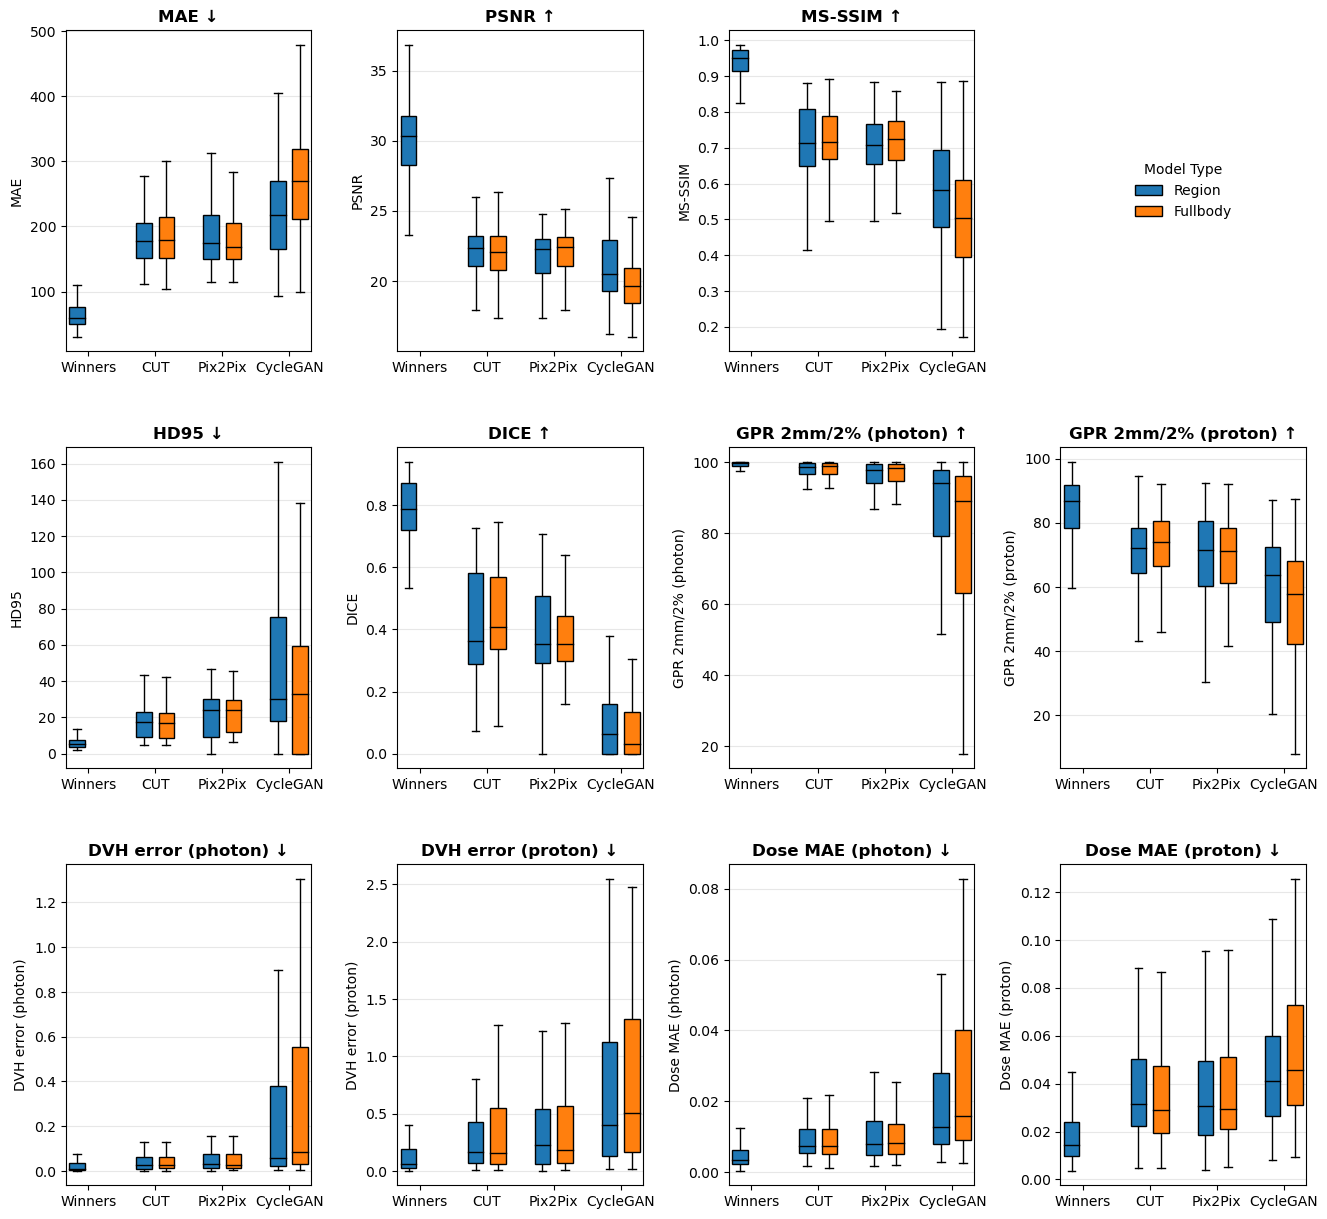

In [8]:
metrics_row1 = ['MAE', 'PSNR', 'MS-SSIM']
metrics_row2 = ['HD95', 'DICE', 'GPR 2mm/2% (photon)', 'GPR 2mm/2% (proton)']
metrics_row3 = ['DVH error (photon)', 'DVH error (proton)', 'Dose MAE (photon)', 'Dose MAE (proton)']

# use the longest row to set the grid width
n_cols = max(len(metrics_row1), len(metrics_row2), len(metrics_row3))

fig = plt.figure(figsize=(4 * n_cols, 15))  # taller for 3 rows
outer = fig.add_gridspec(3, 1, hspace=0.30)

# =========================
# Row 1 (reserve last slot for legend)
# =========================
inner1 = outer[0].subgridspec(1, n_cols, wspace=0.35)
axes1 = [fig.add_subplot(inner1[0, j]) for j in range(n_cols)]

metric_axes_row1 = axes1[:len(metrics_row1)]
legend_ax = axes1[-1]  # last axis reserved for legend

plot_multiple_metrics_with_subplots_on_axes(
    synthrad_results,
    metrics=metrics_row1,
    groups=["model", "region_or_fullbody"],
    legend_title="Model Type",
    fig=fig,
    axes=metric_axes_row1,
    add_legend=False,
    show=False,
)

# --- build legend handles explicitly (matches your plotting logic) ---
dff_leg = synthrad_results.copy()
dff_leg = dff_leg.dropna(subset=list(metrics_row1))

g2 = "region_or_fullbody"
order2 = list(pd.unique(dff_leg[g2]))

cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
colors = {k: (cycle[i % len(cycle)] if cycle else f"C{i}") for i, k in enumerate(order2)}

legend_handles = [Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2]

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="Model Type",
    frameon=False,
    loc="center",
)

# Hide any unused axes in row 1 (between last metric and legend slot)
for ax in axes1[len(metrics_row1):-1]:
    ax.axis("off")

# =========================
# Row 2
# =========================
inner2 = outer[1].subgridspec(1, n_cols, wspace=0.35)
axes2 = [fig.add_subplot(inner2[0, j]) for j in range(n_cols)]

plot_multiple_metrics_with_subplots_on_axes(
    synthrad_results,
    metrics=metrics_row2,
    groups=["model", "region_or_fullbody"],
    legend_title="Model Type",
    fig=fig,
    axes=axes2[:len(metrics_row2)],
    add_legend=False,
    show=False,
)

# Hide unused axes in row 2
for ax in axes2[len(metrics_row2):]:
    ax.axis("off")

# =========================
# Row 3
# =========================
inner3 = outer[2].subgridspec(1, n_cols, wspace=0.35)
axes3 = [fig.add_subplot(inner3[0, j]) for j in range(n_cols)]

plot_multiple_metrics_with_subplots_on_axes(
    synthrad_results,
    metrics=metrics_row3,
    groups=["model", "region_or_fullbody"],
    legend_title="Model Type",
    fig=fig,
    axes=axes3[:len(metrics_row3)],
    add_legend=False,
    show=False,
)

# Hide unused axes in row 3
for ax in axes3[len(metrics_row3):]:
    ax.axis("off")

# plt.tight_layout()
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Overview_Chart_Synthrad.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Overview_Chart_Synthrad.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Own Volume-level but on Synthrad-Masks

=======================results chart======================


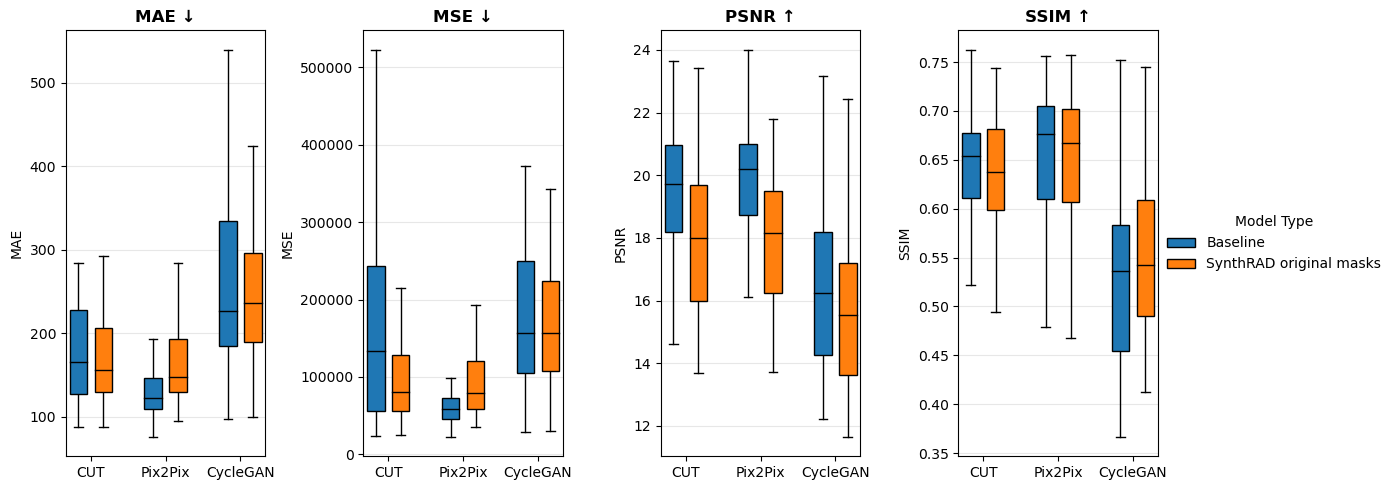

\begin{table}
\centering
\caption{Experiment 1 Results By Mask Type]{\textsc{Experiment 1 Results By Mask Type.} Experiment 1 results aggregated over the three SynthRAD25 anatomical regions (abdomen, head-neck, thorax) to assess effect of mask quality on metrics based on own image similarity evaluation (mean $\pm$ std), test set ($n=87$).}
\label{tab:e1_own_compare_masks}
\begin{tabular}{l l l c c c c}
\toprule
   model &                   masks &     region &             MAE &               MSE &         PSNR &          SSIM \\
\midrule
     CUT &                Baseline & AB, HN, TH & 206.86 ± 129.69 & 204'223 ± 207'394 & 19.09 ± 2.83 & 0.633 ± 0.071 \\
     CUT & SynthRAD original masks & AB, HN, TH &  168.78 ± 47.80 &   95'752 ± 47'226 & 17.85 ± 2.14 & 0.635 ± 0.057 \\
CycleGAN &                Baseline & AB, HN, TH & 252.52 ± 102.59 & 176'238 ± 110'117 & 16.59 ± 2.91 & 0.531 ± 0.097 \\
CycleGAN & SynthRAD original masks & AB, HN, TH &  239.53 ± 79.97 &  157'384 ± 75'628 & 16.02 ± 

metric,model,masks,region,MAE,MSE,PSNR,SSIM
0,CUT,Baseline,"AB, HN, TH",206.86 ± 129.69,204'223 ± 207'394,19.09 ± 2.83,0.633 ± 0.071
1,CUT,SynthRAD original masks,"AB, HN, TH",168.78 ± 47.80,95'752 ± 47'226,17.85 ± 2.14,0.635 ± 0.057
2,CycleGAN,Baseline,"AB, HN, TH",252.52 ± 102.59,176'238 ± 110'117,16.59 ± 2.91,0.531 ± 0.097
3,CycleGAN,SynthRAD original masks,"AB, HN, TH",239.53 ± 79.97,157'384 ± 75'628,16.02 ± 2.71,0.551 ± 0.081
4,Pix2Pix,Baseline,"AB, HN, TH",146.99 ± 71.40,83'553 ± 81'055,19.88 ± 1.99,0.655 ± 0.065
5,Pix2Pix,SynthRAD original masks,"AB, HN, TH",163.34 ± 45.61,92'284 ± 42'865,17.94 ± 1.94,0.652 ± 0.066


In [9]:
# Data loading
data_info_ex1_volume = pd.DataFrame(
    [
        ["Fullbody", "Baseline", "cut_synthrad_allregions_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "pix2pix_synthrad_allregion_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "cyclegan_allregions_final/test_50/test_metrics_over_volume.csv"],
    ],
    columns=["region_or_fullbody", "masks", "path"],
)
BASE_PATH = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/100results/"
all_data_baseline = load_and_concat(data_info_ex1_volume, BASE_PATH)
BASE_PATH = "/local/scratch/datasets/FullbodySCT/test_with_original_masks/100results/"
all_data_original_masks = load_and_concat(data_info_ex1_volume, BASE_PATH)
all_data_original_masks["masks"] = "SynthRAD original masks"
all_data = pd.concat([all_data_baseline, all_data_original_masks])
all_data = all_data[all_data["bodyregion"].isin(["AB","TH","HN"])]
masked, unmasked = split_masked_unmasked(all_data)

print("=======================results chart======================")
fig = plot_multiple_metrics_with_subplots(
    masked,
    metrics=["MAE", "MSE", "PSNR", "SSIM"],
    groups=["model", "masks"],
    legend_title="Model Type",
    # title="Ex1: Fullbody vs. Region-Specific Models, own Image Similarity-based Evaluation",
)
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Overview_Chart_Own_Compare_Masks.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex1_Overview_Chart_Own_Compare_Masks.pdf", format="pdf", bbox_inches="tight")


results_table = metrics_mean_std_by_region_model(masked, group_cols=("model", "masks"))
results_table["region"] = "AB, HN, TH"
results_table = results_table[['model', 'masks', 'region', 'MAE', 'MSE', 'PSNR', 'SSIM']]
latex_results_table = results_table.to_latex(
        index=False,
        escape=False,
        column_format="l l l c c c c",
        caption="Experiment 1 Results By Mask Type]{\\textsc{Experiment 1 Results By Mask Type.} Experiment 1 results aggregated over the three SynthRAD25 anatomical regions (abdomen, head-neck, thorax) to assess effect of mask quality on metrics based on own image similarity evaluation (mean $\pm$ std), test set ($n=87$).",
        label="tab:e1_own_compare_masks",
    )
print(latex_results_table)
results_table

# Experiment 2

## Volume-level metrics

In [10]:
# Data loading
data_info_ex2_volume = pd.DataFrame(
    [
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "99th Percentile", "2_experiment_cut_synthrad_abdomen_32p99/test_50/test_metrics_over_volume.csv"],
        ["Region", "Nyul", "2_experiment_cut_synthrad_abdomen_33nyul/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08", "2_experiment_cut_synthrad_abdomen_34normalized_n4_08LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "Separate 1st Layer", "2_experiment_cut_synthrad_abdomen_sep_first_layer/test_50/test_metrics_over_volume.csv"],

        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "99th Percentile", "2_experiment_pix2pix_synthrad_abdomen_32p99/test_50/test_metrics_over_volume.csv"],
        ["Region", "Nyul", "2_experiment_pix2pix_synthrad_abdomen_33nyul/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08", "2_experiment_pix2pix_synthrad_abdomen_34normalized_n4_08LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "Separate 1st Layer", "2_experiment_pix2pix_synthrad_abdomen_sep_input_layers/test_50/test_metrics_over_volume.csv"],

        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "99th Percentile", "2_experiment_cyclegan_abdomen_32p99/test_50/test_metrics_over_volume.csv"],
        ["Region", "Nyul", "2_experiment_cyclegan_abdomen_33nyul/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08", "2_experiment_cyclegan_abdomen_34normalized_n4_08LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "Separate 1st Layer", "2_experiment_cyclegan_abdomen_sep_first_layer/test_50/test_metrics_over_volume.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex2_volume)
masked, unmasked = split_masked_unmasked(all_data)

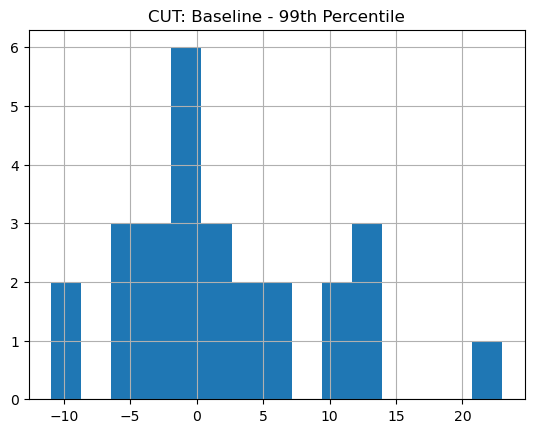

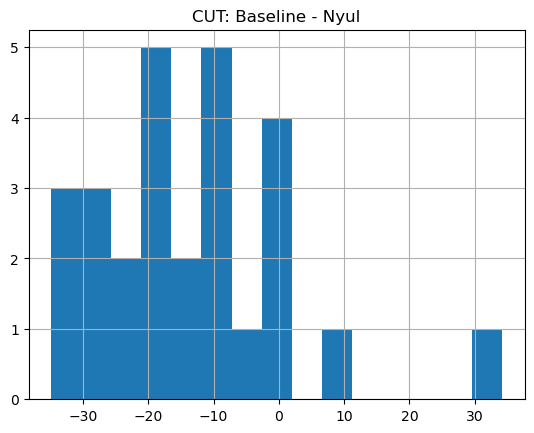

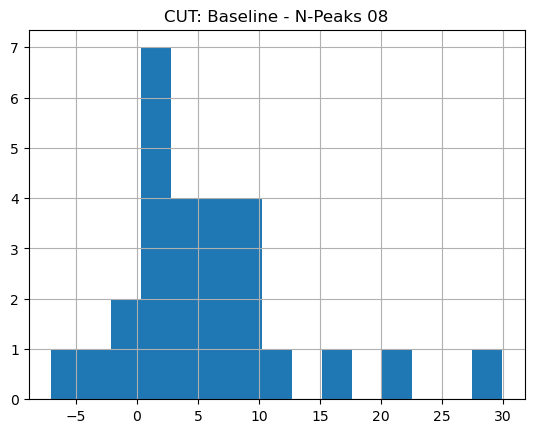

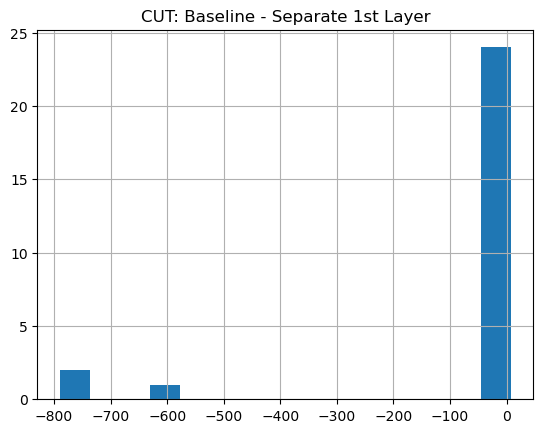

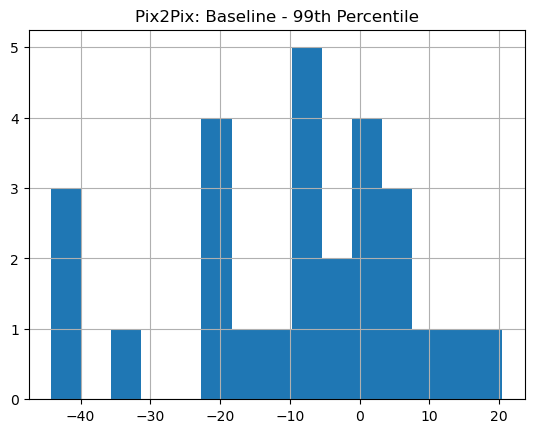

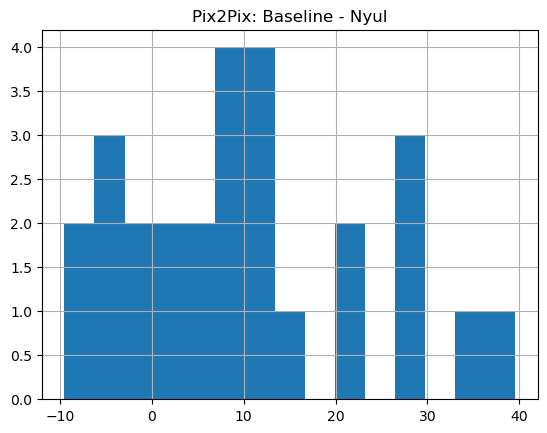

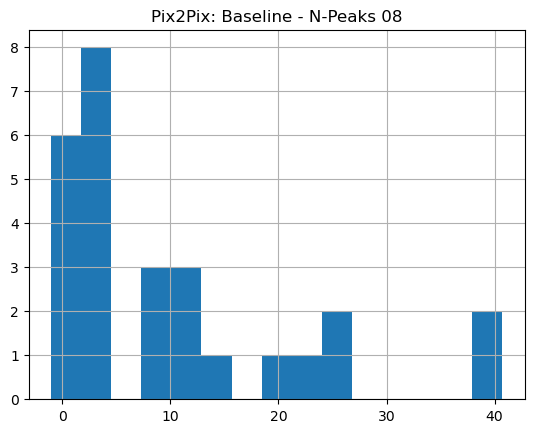

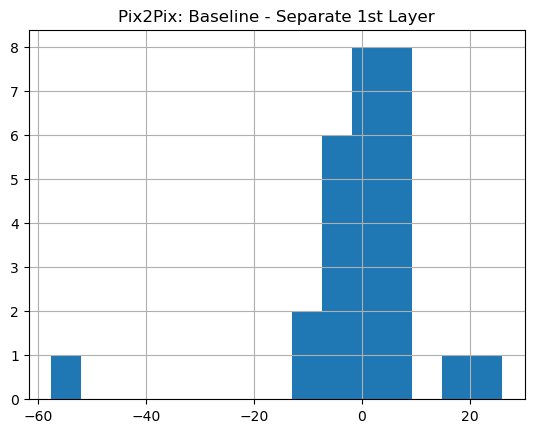

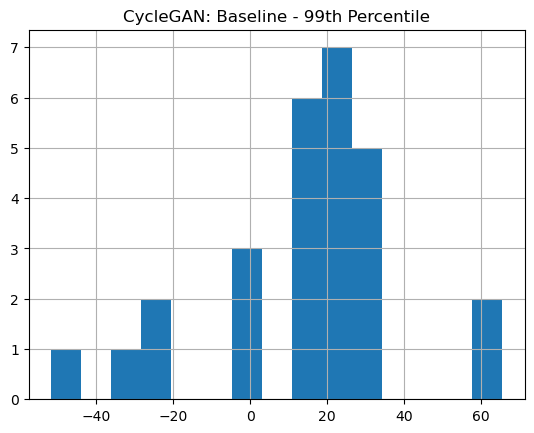

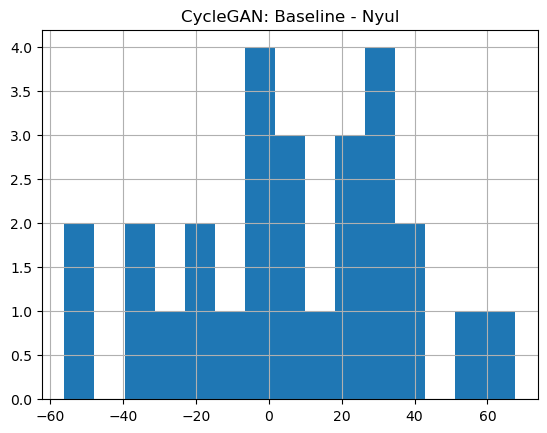

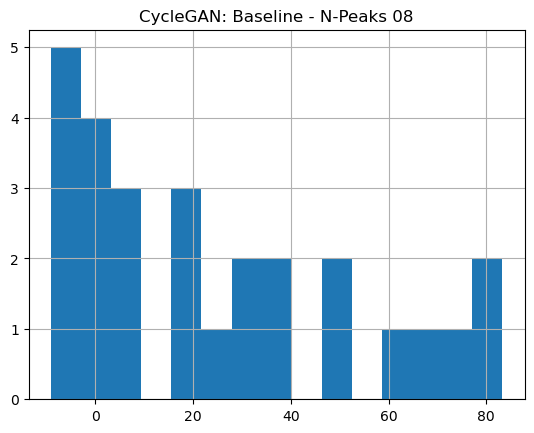

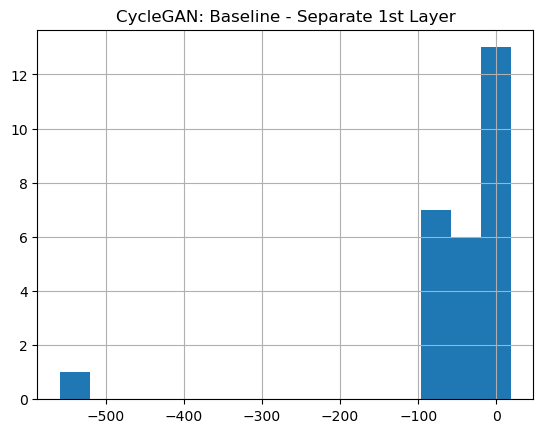

                                             T   p_value  effect_size_RBC   n
model    comparison                                                          
CUT      Baseline vs 99th Percentile     162.0  0.524345            0.143  27
         Baseline vs Nyul                 41.0  0.000395           -0.783  27
         Baseline vs N-Peaks 08           41.0  0.000395            0.783  27
         Baseline vs Separate 1st Layer   77.0  0.007389           -0.593  27
Pix2Pix  Baseline vs 99th Percentile      85.0  0.012897           -0.550  27
         Baseline vs Nyul                 49.0  0.000804            0.741  27
         Baseline vs N-Peaks 08            9.0  0.000016            0.952  27
         Baseline vs Separate 1st Layer  155.0  0.420913            0.180  27
CycleGAN Baseline vs 99th Percentile      81.0  0.009803            0.571  27
         Baseline vs Nyul                148.0  0.330547            0.217  27
         Baseline vs N-Peaks 08           52.0  0.001040        

In [11]:
# Check assumption "Symmetry of paired differences"
for model in masked["model"].unique():
    sub = masked[masked["model"] == model]
    wide = sub.pivot_table(index="volume_id", columns="preprocessing", values="MAE")
    for condition in ["99th Percentile", "Nyul", "N-Peaks 08", "Separate 1st Layer"]:
        diffs = wide["Baseline"] - wide[condition]
        diffs.hist(bins=15)
        plt.title(f"{model}: Baseline - {condition}")
        plt.show()

wilcoxon_results = calculate_wilcoxon_vs_baseline(masked, metric="MAE", baseline="Baseline", within="preprocessing", subject="volume_id")
print(wilcoxon_results)

In [12]:
by_center = masked.copy()
by_center["center"] = by_center["volume_id"].str[6]
by_center = metrics_mean_std_by_region_model(by_center, group_cols=("model", "preprocessing", "center"),)
by_center_out = by_center.copy()
by_center_out = by_center_out[by_center_out["preprocessing"]=="Separate 1st Layer"].drop(columns=["preprocessing"])
by_center_out = by_center_out.to_latex(
        index=False,
        escape=False,
        column_format="l l c c c c",
        caption="Image similarity metrics (mean $\\pm$ std)",
        label="tab:e3_detail_sep_input_layer",
    )
print(by_center_out)

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:e3_detail_sep_input_layer}
\begin{tabular}{l l c c c c}
\toprule
   model & center &             MAE &               MSE &         PSNR &          SSIM \\
\midrule
     CUT &      A &  104.50 ± 17.15 &   34'609 ± 12'051 & 22.47 ± 1.62 & 0.637 ± 0.027 \\
     CUT &      B &  127.67 ± 14.85 &   56'673 ± 13'081 & 20.19 ± 1.09 & 0.606 ± 0.026 \\
     CUT &      C &  869.37 ± 22.40 &  847'066 ± 33'266 &  8.47 ± 0.25 & 0.251 ± 0.030 \\
CycleGAN &      A &  122.05 ± 23.98 &   48'898 ± 16'822 & 20.82 ± 1.52 & 0.600 ± 0.033 \\
CycleGAN &      B &  261.23 ± 31.10 &  175'194 ± 29'605 & 14.99 ± 0.85 & 0.436 ± 0.039 \\
CycleGAN &      C & 370.02 ± 414.55 & 311'525 ± 438'333 & 16.26 ± 6.98 & 0.499 ± 0.193 \\
 Pix2Pix &      A &   92.23 ± 19.96 &   33'461 ± 12'013 & 22.17 ± 1.39 & 0.676 ± 0.036 \\
 Pix2Pix &      B &  132.16 ± 24.86 &   64'474 ± 20'267 & 19.64 ± 1.24 & 0.606 ± 0.045 \\
 Pix2Pix &      C &  130.77 

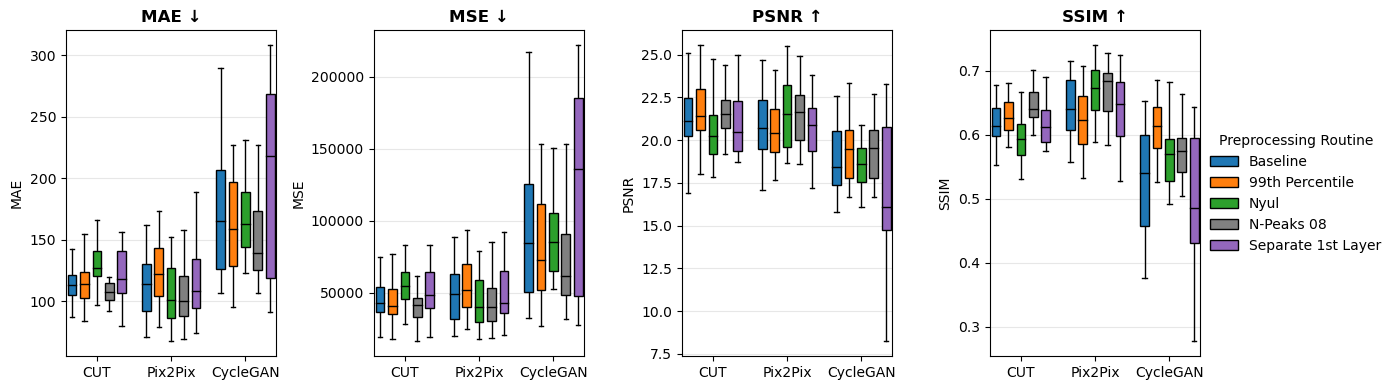

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:e3_own}
\begin{tabular}{l l c c c c}
\toprule
   model &      preprocessing &             MAE &               MSE &         PSNR &          SSIM \\
\midrule
     CUT &    99th Percentile &  117.37 ± 27.29 &   46'183 ± 25'365 & 21.63 ± 1.77 & 0.627 ± 0.027 \\
     CUT &           Baseline &  119.20 ± 29.66 &   48'703 ± 29'054 & 21.38 ± 1.77 & 0.620 ± 0.031 \\
     CUT &         N-Peaks 08 &  113.56 ± 25.27 &   44'672 ± 23'800 & 21.71 ± 1.65 & 0.646 ± 0.028 \\
     CUT &               Nyul &  132.47 ± 24.92 &   59'346 ± 23'441 & 20.61 ± 1.78 & 0.593 ± 0.034 \\
     CUT & Separate 1st Layer & 201.50 ± 241.40 & 136'323 ± 256'716 & 19.73 ± 4.37 & 0.578 ± 0.121 \\
CycleGAN &    99th Percentile &  159.64 ± 40.22 &   80'243 ± 34'677 & 19.36 ± 1.90 & 0.608 ± 0.045 \\
CycleGAN &           Baseline &  174.47 ± 54.34 &   94'561 ± 51'400 & 18.84 ± 2.10 & 0.528 ± 0.082 \\
CycleGAN &         N-Peaks 08 &  149.97 ±

metric,model,preprocessing,MAE,MSE,PSNR,SSIM
0,CUT,99th Percentile,117.37 ± 27.29,46'183 ± 25'365,21.63 ± 1.77,0.627 ± 0.027
1,CUT,Baseline,119.20 ± 29.66,48'703 ± 29'054,21.38 ± 1.77,0.620 ± 0.031
2,CUT,N-Peaks 08,113.56 ± 25.27,44'672 ± 23'800,21.71 ± 1.65,0.646 ± 0.028
3,CUT,Nyul,132.47 ± 24.92,59'346 ± 23'441,20.61 ± 1.78,0.593 ± 0.034
4,CUT,Separate 1st Layer,201.50 ± 241.40,136'323 ± 256'716,19.73 ± 4.37,0.578 ± 0.121
5,CycleGAN,99th Percentile,159.64 ± 40.22,80'243 ± 34'677,19.36 ± 1.90,0.608 ± 0.045
6,CycleGAN,Baseline,174.47 ± 54.34,94'561 ± 51'400,18.84 ± 2.10,0.528 ± 0.082
7,CycleGAN,N-Peaks 08,149.97 ± 30.28,70'867 ± 28'632,19.44 ± 1.68,0.571 ± 0.037
8,CycleGAN,Nyul,168.81 ± 34.36,89'789 ± 29'866,18.47 ± 1.44,0.565 ± 0.042
9,CycleGAN,Separate 1st Layer,221.77 ± 145.26,143'566 ± 150'188,17.29 ± 3.56,0.504 ± 0.100


In [13]:
fig = plot_multiple_metrics_with_subplots(
    masked,
    metrics=['MAE', 'MSE', 'PSNR', 'SSIM'],
    groups=["model", "preprocessing"],
    legend_title="Preprocessing Routine",
    figsize_per_subplot = (4, 4),
    # title="Experiment 2: Preprocessing Routine",
)
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex2_Overview_Chart_Own_Report.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex2_Overview_Chart_Own_Report.pdf", format="pdf", bbox_inches="tight")

results_table = metrics_mean_std_by_region_model(masked, group_cols=("model", "preprocessing"),)
latex_results_table = results_table.to_latex(
        index=False,
        escape=False,
        column_format="l l c c c c",
        caption="Image similarity metrics (mean $\\pm$ std)",
        label="tab:e3_own",
    )
print(latex_results_table)
results_table

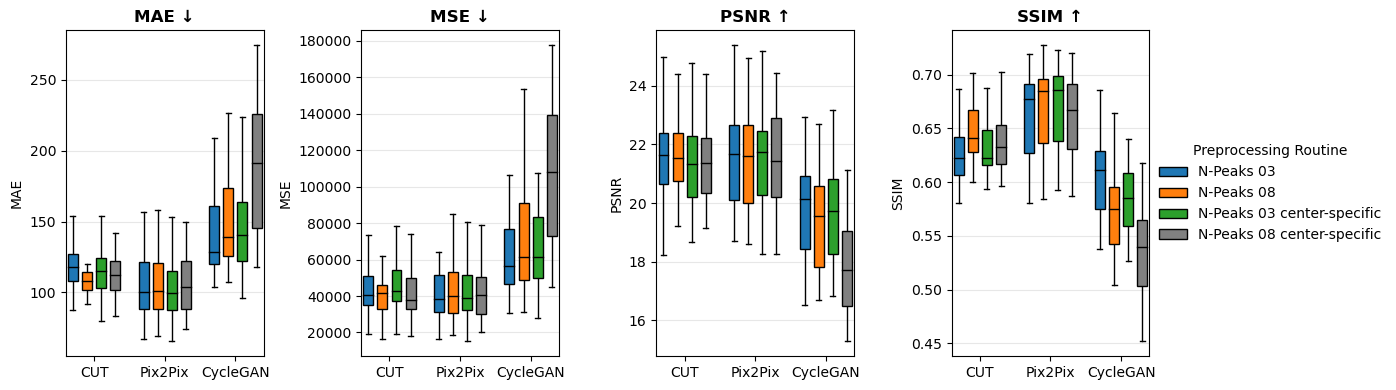

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:e3_own}
\begin{tabular}{l l c c c c}
\toprule
   model &              preprocessing &            MAE &              MSE &         PSNR &          SSIM \\
\midrule
     CUT &                 N-Peaks 03 & 121.40 ± 25.60 &  46'555 ± 24'330 & 21.75 ± 1.86 & 0.626 ± 0.027 \\
     CUT & N-Peaks 03 center-specific & 120.69 ± 35.32 &  51'488 ± 31'836 & 21.30 ± 2.05 & 0.629 ± 0.030 \\
     CUT &                 N-Peaks 08 & 113.56 ± 25.27 &  44'672 ± 23'800 & 21.71 ± 1.65 & 0.646 ± 0.028 \\
     CUT & N-Peaks 08 center-specific & 119.57 ± 36.74 &  47'945 ± 33'792 & 21.16 ± 1.69 & 0.633 ± 0.033 \\
CycleGAN &                 N-Peaks 03 & 141.39 ± 31.43 &  65'766 ± 29'067 & 19.85 ± 1.70 & 0.603 ± 0.036 \\
CycleGAN & N-Peaks 03 center-specific & 147.00 ± 34.52 &  70'421 ± 32'339 & 19.64 ± 1.64 & 0.584 ± 0.034 \\
CycleGAN &                 N-Peaks 08 & 149.97 ± 30.28 &  70'867 ± 28'632 & 19.44 ± 1.68 & 0.571 ± 0.

metric,model,preprocessing,MAE,MSE,PSNR,SSIM
0,CUT,N-Peaks 03,121.40 ± 25.60,46'555 ± 24'330,21.75 ± 1.86,0.626 ± 0.027
1,CUT,N-Peaks 03 center-specific,120.69 ± 35.32,51'488 ± 31'836,21.30 ± 2.05,0.629 ± 0.030
2,CUT,N-Peaks 08,113.56 ± 25.27,44'672 ± 23'800,21.71 ± 1.65,0.646 ± 0.028
3,CUT,N-Peaks 08 center-specific,119.57 ± 36.74,47'945 ± 33'792,21.16 ± 1.69,0.633 ± 0.033
4,CycleGAN,N-Peaks 03,141.39 ± 31.43,65'766 ± 29'067,19.85 ± 1.70,0.603 ± 0.036
5,CycleGAN,N-Peaks 03 center-specific,147.00 ± 34.52,70'421 ± 32'339,19.64 ± 1.64,0.584 ± 0.034
6,CycleGAN,N-Peaks 08,149.97 ± 30.28,70'867 ± 28'632,19.44 ± 1.68,0.571 ± 0.037
7,CycleGAN,N-Peaks 08 center-specific,191.99 ± 46.03,107'480 ± 39'909,17.79 ± 1.68,0.533 ± 0.045
8,Pix2Pix,N-Peaks 03,106.22 ± 27.49,44'813 ± 23'263,21.59 ± 1.71,0.662 ± 0.040
9,Pix2Pix,N-Peaks 03 center-specific,105.28 ± 29.34,44'904 ± 25'176,21.65 ± 1.84,0.671 ± 0.039


In [14]:
# Data loading
data_info_ex2_volume = pd.DataFrame(
    [
        ["Region", "N-Peaks 03", "2_experiment_cut_synthrad_abdomen_34normalized_n4_03LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08", "2_experiment_cut_synthrad_abdomen_34normalized_n4_08LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 03 center-specific", "2_experiment_cut_synthrad_abdomen_34normalized_n4_centerspecific_03LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08 center-specific", "2_experiment_cut_synthrad_abdomen_34normalized_n4_centerspecific_08LIC/test_50/test_metrics_over_volume.csv"],


        ["Region", "N-Peaks 03", "2_experiment_pix2pix_synthrad_abdomen_34normalized_n4_03LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08", "2_experiment_pix2pix_synthrad_abdomen_34normalized_n4_08LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 03 center-specific", "2_experiment_pix2pix_synthrad_abdomen_34normalized_n4_centerspecific_03LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08 center-specific", "2_experiment_pix2pix_synthrad_abdomen_34normalized_n4_centerspecific_08LIC/test_50/test_metrics_over_volume.csv"],

        ["Region", "N-Peaks 03", "2_experiment_cyclegan_abdomen_34normalized_n4_03LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08", "2_experiment_cyclegan_abdomen_34normalized_n4_08LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 03 center-specific", "2_experiment_cyclegan_abdomen_34normalized_n4_centerspecific_03LIC/test_50/test_metrics_over_volume.csv"],
        ["Region", "N-Peaks 08 center-specific", "2_experiment_cyclegan_abdomen_34normalized_n4_centerspecific_08LIC/test_50/test_metrics_over_volume.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)



all_data = load_and_concat(data_info_ex2_volume)
masked, unmasked = split_masked_unmasked(all_data)

fig = plot_multiple_metrics_with_subplots(
    masked,
    metrics=['MAE', 'MSE', 'PSNR', 'SSIM'],
    groups=["model", "preprocessing"],
    legend_title="Preprocessing Routine",
    figsize_per_subplot = (4, 4),
    # title="Experiment 2: Preprocessing Routine",
)
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex2_Overview_Chart_Own_Appendix.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex2_Overview_Chart_Own_Appendix.pdf", format="pdf", bbox_inches="tight")

results_table = metrics_mean_std_by_region_model(masked, group_cols=("model", "preprocessing"),)
latex_results_table = results_table.to_latex(
        index=False,
        escape=False,
        column_format="l l c c c c",
        caption="Image similarity metrics (mean $\\pm$ std)",
        label="tab:e3_own",
    )
print(latex_results_table)
results_table

# Experiment 3

## Volume-level metrics

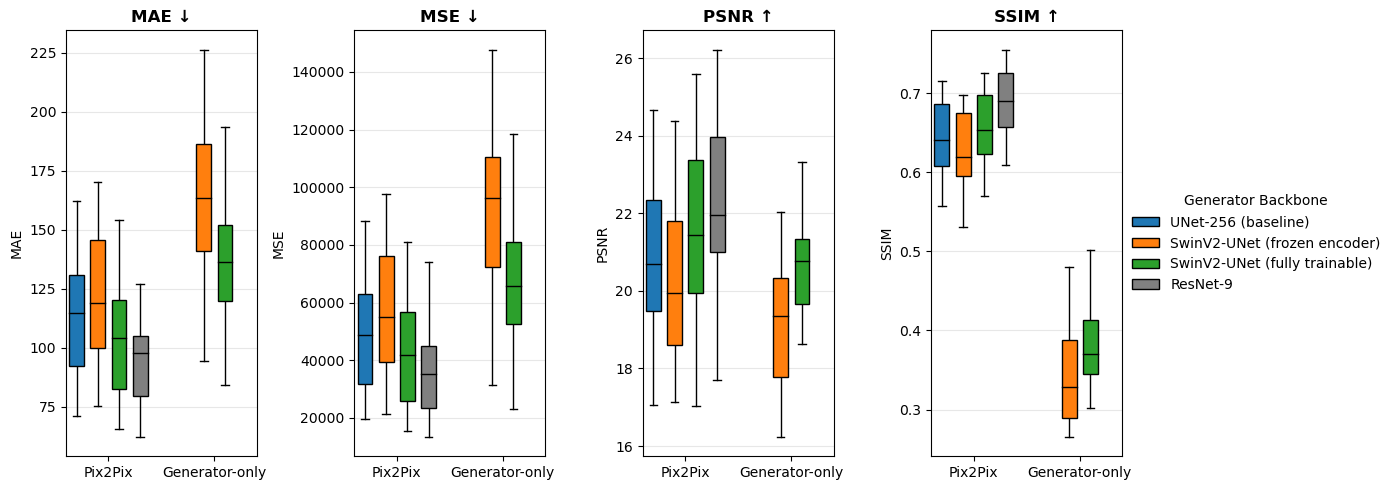

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:e3_own}
\begin{tabular}{l l c c c c}
\toprule
         model &                      backbone &            MAE &             MSE &         PSNR &          SSIM \\
\midrule
Generator-only &  SwinV2-UNet (frozen encoder) & 164.91 ± 32.27 & 92'217 ± 28'674 & 19.21 ± 1.54 & 0.347 ± 0.065 \\
Generator-only & SwinV2-UNet (fully trainable) & 135.34 ± 24.31 & 66'205 ± 22'444 & 20.67 ± 1.29 & 0.382 ± 0.055 \\
       Pix2Pix &                      ResNet-9 &  98.51 ± 31.93 & 39'502 ± 27'219 & 22.27 ± 2.13 & 0.689 ± 0.047 \\
       Pix2Pix &  SwinV2-UNet (frozen encoder) & 125.06 ± 36.44 & 60'394 ± 31'858 & 20.35 ± 2.06 & 0.627 ± 0.050 \\
       Pix2Pix & SwinV2-UNet (fully trainable) & 108.24 ± 35.93 & 46'613 ± 30'811 & 21.55 ± 2.14 & 0.655 ± 0.048 \\
       Pix2Pix &           UNet-256 (baseline) & 116.94 ± 35.40 & 53'867 ± 30'646 & 20.84 ± 1.95 & 0.644 ± 0.049 \\
\bottomrule
\end{tabular}
\end{table}



metric,model,backbone,MAE,MSE,PSNR,SSIM
0,Generator-only,SwinV2-UNet (frozen encoder),164.91 ± 32.27,92'217 ± 28'674,19.21 ± 1.54,0.347 ± 0.065
1,Generator-only,SwinV2-UNet (fully trainable),135.34 ± 24.31,66'205 ± 22'444,20.67 ± 1.29,0.382 ± 0.055
2,Pix2Pix,ResNet-9,98.51 ± 31.93,39'502 ± 27'219,22.27 ± 2.13,0.689 ± 0.047
3,Pix2Pix,SwinV2-UNet (frozen encoder),125.06 ± 36.44,60'394 ± 31'858,20.35 ± 2.06,0.627 ± 0.050
4,Pix2Pix,SwinV2-UNet (fully trainable),108.24 ± 35.93,46'613 ± 30'811,21.55 ± 2.14,0.655 ± 0.048
5,Pix2Pix,UNet-256 (baseline),116.94 ± 35.40,53'867 ± 30'646,20.84 ± 1.95,0.644 ± 0.049


In [15]:
# Data loading
data_info_ex3_volume = pd.DataFrame(
    [
        ["Region", "Baseline", "UNet-256 (baseline)", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "SwinV2-UNet (frozen encoder)", "3_experiment_pix2pix_abdomen_swin_v2_frozen_low_lr/test_100/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "SwinV2-UNet (fully trainable)", "3_experiment_pix2pix_abdomen_swin_v2_low_lr/test_100/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "ResNet-9", "3_experiment_pix2pix_abdomen_resnet/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "SwinV2-UNet (frozen encoder)", "3_experiment_pure_abdomen_swin_v2_frozen_low_lr/test_100/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "SwinV2-UNet (fully trainable)", "3_experiment_pure_abdomen_swin_v2_low_lr/test_100/test_metrics_over_volume.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "backbone", "path"],
)

all_data = load_and_concat(data_info_ex3_volume)
masked, unmasked = split_masked_unmasked(all_data)

fig = plot_multiple_metrics_with_subplots(
    masked,
    metrics=['MAE', 'MSE', 'PSNR', 'SSIM'],
    groups=["model", "backbone"],
    legend_title="Generator Backbone",
    # title="Experiment 3: UNet vs. SwinV2-UNet Models",
)
# fig.savefig("/home/user/nschuler/fullbody-sCT/Ex3_Overview_Chart_Own.png", dpi=300, bbox_inches="tight")
fig.savefig("/home/user/nschuler/fullbody-sCT/Ex3_Overview_Chart_Own.pdf", format="pdf", bbox_inches="tight")

results_table = metrics_mean_std_by_region_model(masked, group_cols=("model", "backbone"),)
latex_results_table = results_table.to_latex(
        index=False,
        escape=False,
        column_format="l l c c c c",
        caption="Image similarity metrics (mean $\\pm$ std)",
        label="tab:e3_own",
    )
print(latex_results_table)
results_table